# Validación Cruzada K-Fold

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Carga y Exploración del Conjunto de Datos

In [3]:
file_path = 'Datasets/bank-additional-full.csv'
try:
    df = pd.read_csv(file_path, sep=';') # Este dataset usa ';' como separador
    print(f"Dataset '{file_path}' cargado exitosamente.")
except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no se encontró. Asegúrate de que esté en la misma ruta o proporciona la ruta correcta.")
  

Dataset 'Datasets/bank-additional-full.csv' cargado exitosamente.


# Explorar el conjunto de datos

In [4]:
print(df.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
print(df.describe())

               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000  
mean       0.081886       93.575664     -40.502600      3.621291   5167.035911  
std        1.570960        0.578840       4.628198    

# Verificar distribución de la variable objetivo 'y'

In [7]:
print("\n--- Distribución de la variable objetivo 'y' ---")
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True))


--- Distribución de la variable objetivo 'y' ---
y
no     36548
yes     4640
Name: count, dtype: int64
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


# Preprocesamiento de Datos

In [8]:
df_processed = df.copy()

# Identificar columnas categóricas y numéricas

In [9]:
categorical_cols = df_processed.select_dtypes(include=['object']).columns
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns

# 1. Codificación de la variable objetivo 'y'

In [10]:
if 'y' in categorical_cols:
    le = LabelEncoder()
    df_processed['y'] = le.fit_transform(df_processed['y'])
    print(f"Etiquetas codificadas para 'y': {list(le.classes_)} -> {list(le.transform(le.classes_))}")
    categorical_cols = categorical_cols.drop('y', errors='ignore') # Quitar 'y' de las categóricas a OHE

Etiquetas codificadas para 'y': ['no', 'yes'] -> [np.int64(0), np.int64(1)]


# Separar características (X) y variable objetivo (y)

In [11]:
if 'y' in df_processed.columns:
    X = df_processed.drop('y', axis=1)
    y = df_processed['y']
else:
    print("\n¡Advertencia! No se encontró la columna 'y' después de procesar. Asegúrate de que tu dataset tiene una variable objetivo llamada 'y'.")
    print("Asumiendo que la última columna es la variable objetivo para demostración.")
    X = df_processed.iloc[:, :-1]
    y = df_processed.iloc[:, -1]

# 2. Aplicar One-Hot Encoding a las demás columnas categóricas

In [12]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"\nNúmero de características después de One-Hot Encoding: {X.shape[1]}")


Número de características después de One-Hot Encoding: 53


# 3. Escalado de características numéricas

In [13]:
numerical_features_to_scale = [col for col in numerical_cols if col in X.columns]

In [14]:
if numerical_features_to_scale:
    scaler = StandardScaler()
    X[numerical_features_to_scale] = scaler.fit_transform(X[numerical_features_to_scale])
    print("\nCaracterísticas numéricas escaladas.")
else:
    print("\nNo se encontraron características numéricas para escalar o ya se procesaron.")

print("\n--- Primeras 5 filas del dataset preprocesado (Características X) ---")
print(X.head())
print("\n--- Primeras 5 filas de la variable objetivo (y) ---")
print(y.head())


Características numéricas escaladas.

--- Primeras 5 filas del dataset preprocesado (Características X) ---
        age  duration  campaign     pdays  previous  emp.var.rate  \
0  1.533034  0.010471 -0.565922  0.195414 -0.349494      0.648092   
1  1.628993 -0.421501 -0.565922  0.195414 -0.349494      0.648092   
2 -0.290186 -0.124520 -0.565922  0.195414 -0.349494      0.648092   
3 -0.002309 -0.413787 -0.565922  0.195414 -0.349494      0.648092   
4  1.533034  0.187888 -0.565922  0.195414 -0.349494      0.648092   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  ...  month_may  \
0        0.722722       0.886447    0.71246      0.33168  ...       True   
1        0.722722       0.886447    0.71246      0.33168  ...       True   
2        0.722722       0.886447    0.71246      0.33168  ...       True   
3        0.722722       0.886447    0.71246      0.33168  ...       True   
4        0.722722       0.886447    0.71246      0.33168  ...       True   

   month_nov  month

# Selección del Modelo de Machine Learning

In [16]:
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=500) # Ajusta max_iter si hay advertencias de convergencia

print(f"Modelo seleccionado: {type(model).__name__}")

Modelo seleccionado: LogisticRegression


# Implementación de K-Fold Cross-Validation

In [18]:
n_splits = 5 # Número de 'folds'
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42) 

In [19]:
# Listas para almacenar las métricas de cada fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

In [20]:
print(f"Iniciando validación cruzada con K-Fold (n_splits={n_splits})...")

fold_idx = 1
for train_index, test_index in kf.split(X):
    # Dividir los datos en conjuntos de entrenamiento y prueba para el fold actual
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Entrenar el modelo con el conjunto de entrenamiento de este fold
    model.fit(X_train, y_train)

    # Realizar predicciones sobre el conjunto de prueba
    y_pred = model.predict(X_test)

    # Calcular y almacenar las métricas para este fold
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1] # Probabilidad de la clase positiva (1)
        roc_auc_scores.append(roc_auc_score(y_test, y_prob))
    else:
        roc_auc_scores.append(np.nan) # Si el modelo no soporta predict_proba

    print(f"\n--- Resultados del Fold {fold_idx} ---")
    print(f"  Accuracy: {accuracy_scores[-1]:.4f}")
    print(f"  Precision: {precision_scores[-1]:.4f}")
    print(f"  Recall: {recall_scores[-1]:.4f}")
    print(f"  F1-Score: {f1_scores[-1]:.4f}")
    if not np.isnan(roc_auc_scores[-1]):
        print(f"  ROC AUC: {roc_auc_scores[-1]:.4f}")

    fold_idx += 1

print("\nValidación cruzada finalizada.")

Iniciando validación cruzada con K-Fold (n_splits=5)...

--- Resultados del Fold 1 ---
  Accuracy: 0.9111
  Precision: 0.6683
  Recall: 0.4310
  F1-Score: 0.5241
  ROC AUC: 0.9349

--- Resultados del Fold 2 ---
  Accuracy: 0.9126
  Precision: 0.6695
  Recall: 0.4259
  F1-Score: 0.5206
  ROC AUC: 0.9379

--- Resultados del Fold 3 ---
  Accuracy: 0.9069
  Precision: 0.6585
  Recall: 0.4194
  F1-Score: 0.5124
  ROC AUC: 0.9310

--- Resultados del Fold 4 ---
  Accuracy: 0.9145
  Precision: 0.6521
  Recall: 0.4248
  F1-Score: 0.5145
  ROC AUC: 0.9366

--- Resultados del Fold 5 ---
  Accuracy: 0.9109
  Precision: 0.6851
  Recall: 0.4177
  F1-Score: 0.5190
  ROC AUC: 0.9348

Validación cruzada finalizada.


# Cálculo y Visualización de los Resultados Finales

In [21]:
print("\n--- Resultados Promedio de la Validación Cruzada ---")
print(f"Accuracy promedio: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"Precision promedio: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
print(f"Recall promedio: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
print(f"F1-Score promedio: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
if not np.all(np.isnan(roc_auc_scores)):
    print(f"ROC AUC promedio: {np.nanmean(roc_auc_scores):.4f} (+/- {np.nanstd(roc_auc_scores):.4f})")


--- Resultados Promedio de la Validación Cruzada ---
Accuracy promedio: 0.9112 (+/- 0.0025)
Precision promedio: 0.6667 (+/- 0.0112)
Recall promedio: 0.4238 (+/- 0.0048)
F1-Score promedio: 0.5181 (+/- 0.0042)
ROC AUC promedio: 0.9350 (+/- 0.0023)


# DataFrame para las métricas

In [23]:
results_df = pd.DataFrame({
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})
if not np.all(np.isnan(roc_auc_scores)):
    results_df['ROC AUC'] = roc_auc_scores

print("\n--- Detalles de las métricas por cada Fold ---")
print(results_df)


--- Detalles de las métricas por cada Fold ---
   Accuracy  Precision    Recall  F1-Score   ROC AUC
0  0.911143   0.668325  0.431016  0.524057  0.934905
1  0.912600   0.669521  0.425926  0.520639  0.937906
2  0.906895   0.658497  0.419355  0.512397  0.930999
3  0.914532   0.652098  0.424829  0.514483  0.936598
4  0.910890   0.685121  0.417722  0.519004  0.934816


# Visualización de la distribución de las métricas

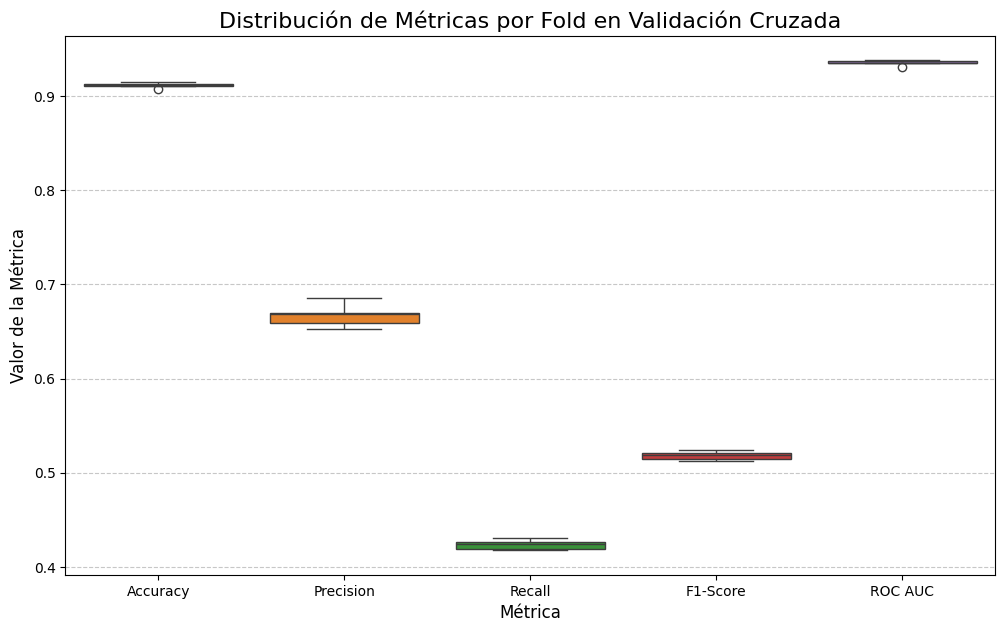

In [24]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=results_df)
plt.title('Distribución de Métricas por Fold en Validación Cruzada', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Métrica', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Gráfico de barras de los promedios con desviación estándar

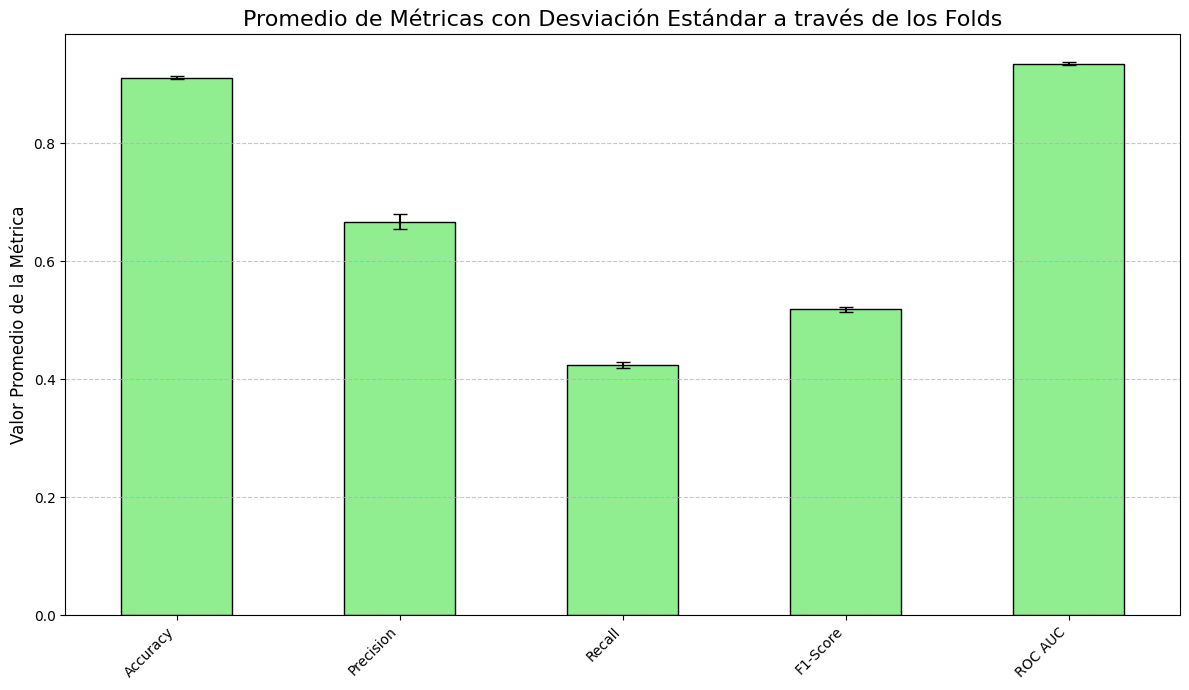

In [25]:
mean_scores = results_df.mean()
std_scores = results_df.std()

plt.figure(figsize=(12, 7))
mean_scores.plot(kind='bar', yerr=std_scores, capsize=5, color='lightgreen', edgecolor='black')
plt.title('Promedio de Métricas con Desviación Estándar a través de los Folds', fontsize=16)
plt.ylabel('Valor Promedio de la Métrica', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Conclusion

In [ ]:
# El modelo muestra una alta exactitud (accuracy 91%), lo que podría parecer bueno inicialmente

# Sin embargo, hay un gran contraste entre la precisión (67%) y el recall (42%), 

# La baja tasa de recall (42%) indica que el modelo está fallando en identificar correctamente muchos 
# de los casos positivos (clientes que sí contratarían el depósito a plazo)

# El F1-Score (52%) refleja mejor el rendimiento real al ser la media armónica entre precisión y recall

# El ROC AUC (93%) muestra que el modelo discrimina bien entre clases a diferentes umbrales, 
# lo que sugiere que el problema podría estar en el umbral de decisión